## Gold Price - Analysis & Forecasting

[![green-arrow-over-gold-bars.jpg](https://i.postimg.cc/XYgHHFT4/green-arrow-over-gold-bars.jpg)](https://postimg.cc/Yvhzj4rs)


### Table of Contents

* [Necessary Package Installation](#section1)
* [1. Setup and Library Imports](#section_1)
* [2. Data Loading and Preparation](#section_2)
* [3. Exploratory Data Analysis](#section3)
    * [3.1 Overview of the Data](#section3.1)
    * [3.2 Time Series Components Analysis](#section3.2)
    * [3.3 Time Aggregation Analysis](#section3.3)
    * [3.4 Analysis in Coefficient of variation](#section3.4)
* [4. Statistical Tests and Advanced Analysis](#section4)
    * [4.1 Stationarity Analysis](#section4.1)
    * [4.2 Structural Break Analysis](#section4.2)
    * [4.3 Volatility Analysis with GARCH](#section4.3)
* [5. Data Preparation for Modeling](#section5)
* [6. Basic Forecasting Models](#section6)
    * [6.1 Linear Regression Model](#section6.1)
    * [6.2 Naive Forecast Model](#section6.2)
    * [6.3 Simple Average Model](#section6.3)
* [7. Moving Average Models](#section7)
* [8. Advanced Time Series Models](#section8)
* [9. Model Comparison](#section9)
* [10. Conclusion](#section10)

# Necessary Package Installation <a class="anchor" id="section1"></a>

In [ ]:
!pip install --upgrade arch
import arch
print("arch version:", arch.__version__)  # Should output 7.2.0+


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 12.6 MB/s eta 0:00:00
arch version: 7.2.0


# 1. Setup and Library Imports <a class="anchor" id="section_1"></a>

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Statistical and time series analysis libraries
from statsmodels.tsa.stattools import adfuller, kpss  # For stationarity tests
from statsmodels.stats.diagnostic import breaks_cusumolsresid, acorr_ljungbox  # For structural break detection
from arch import arch_model      # For GARCH volatility modeling
from statsmodels.graphics.tsaplots import month_plot  # For seasonal plots
from sklearn.metrics import mean_squared_error  # For evaluation metrics
from statsmodels.api import OLS  # For Ordinary Least Squares regression

# Model libraries
from sklearn.linear_model import LinearRegression  # For linear regression modeling
from statsmodels.tsa.api import ExponentialSmoothing  # For Holt-Winters exponential smoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX  # For SARIMA modeling

# Suppress warnings to keep output clean
import warnings
warnings.filterwarnings("ignore")



# 2. Data Loading and Preparation
In this section, we load the gold price dataset and define our evaluation metric.
 <a class="anchor" id="section_2"></a>

In [ ]:
# Data import (assuming kagglehub is already set up)
import kagglehub
import os

print('Data source import complete.')
tunguz_gold_prices_path = kagglehub.dataset_download('tunguz/gold-prices')
print(os.listdir(tunguz_gold_prices_path))

# Load data with proper date parsing
# - parse_dates converts the Date column to datetime
# - index_col sets the Date column as index
# - asfreq('MS') ensures monthly start frequency for time series analysis
df = pd.read_csv(os.path.join(tunguz_gold_prices_path, 'monthly_csv.csv'),
                 parse_dates=['Date'], index_col='Date').asfreq('MS')

# Define Mean Absolute Percentage Error function (used throughout for model evaluation)
def mape(actual, pred):
    """
    Calculate Mean Absolute Percentage Error

    Parameters:
    actual (array): Actual values
    pred (array): Predicted values

    Returns:
    float: MAPE value as percentage
    """
    actual = np.asarray(actual)
    pred = np.asarray(pred)
    epsilon = np.finfo(float).eps  # Prevent division by zero
    return round((np.mean(np.abs(actual-pred)/(np.abs(actual)+epsilon)))*100, 2)


Data source import complete.
['annual_csv.csv', 'monthly_csv.csv']


In [ ]:
df.shape

(847, 1)

# 3. Exploratory Data Analysis <a class="anchor" id="section3"></a>

## 3.1 Overview of the Data
<a class="anchor" id= "section3.1"></a>


Date range: 1950-01-01 to 2020-07-01

Data types:
Price    float64
dtype: object


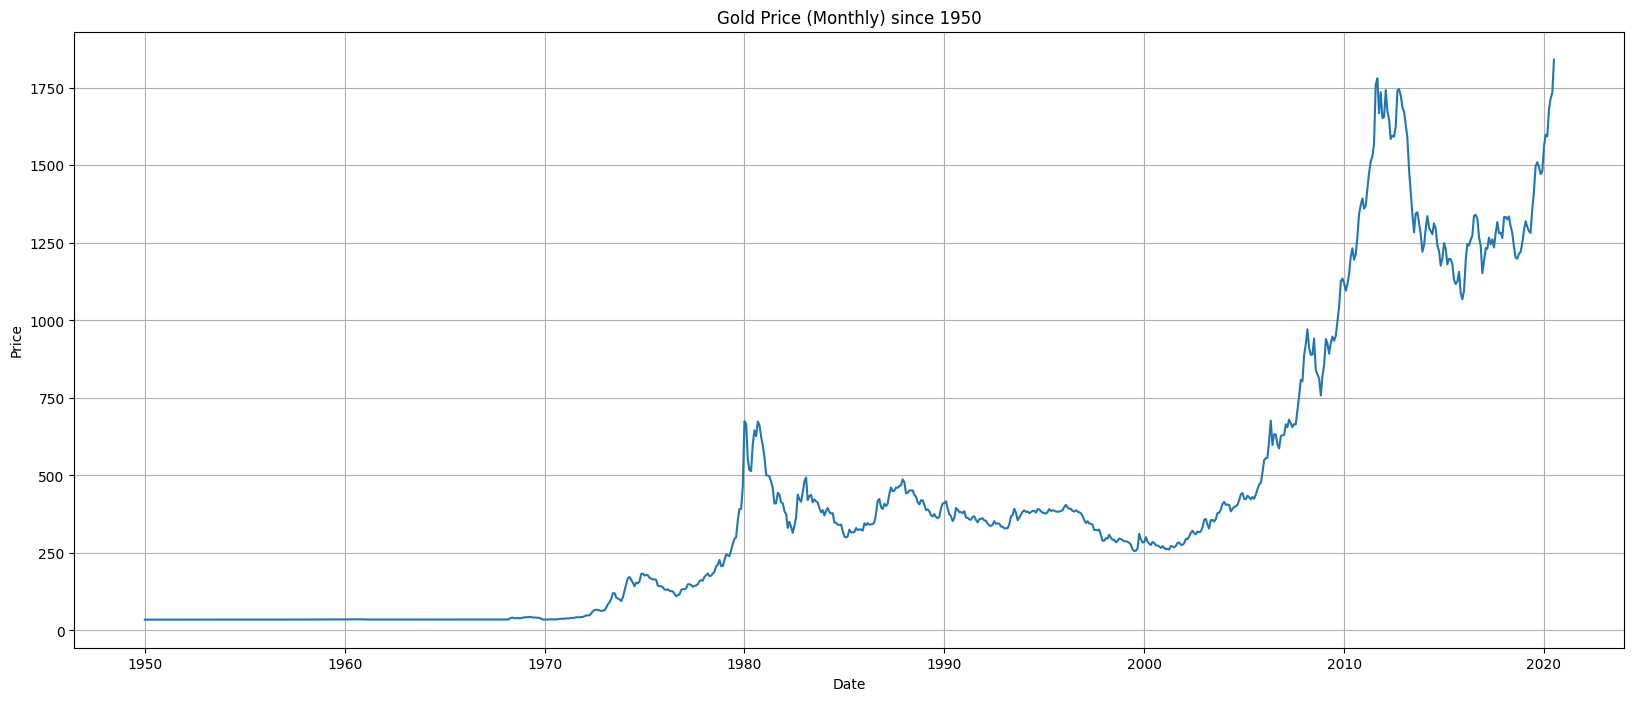

In [ ]:
# Data range and types
print(f"\nDate range: {df.index[0].date()} to {df.index[-1].date()}")
print("\nData types:")
print(df.dtypes)

# Plot the full data
plt.figure(figsize=(20,8))
plt.plot(df['Price'])
plt.title("Gold Price (Monthly) since 1950")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()


**Inference**

1. The Average gold price in last 70 years is **$416.56**

2. **Only 25% of the time**, the gold price is above **$447.07**

3. Highest Gold price ever touched is **$1840.81**

## 3.2 Time Series Components Analysis
Time series data typically consists of four main components:

Trend: The long-term movement in the data

Seasonality: Regular patterns that repeat over fixed intervals

Cyclical Components: Irregular fluctuations without fixed frequency

Random Variations: Unpredictable fluctuations

The following visualizations help us identify these components in gold price data. <a class="anchor" id="section3.2"></a>


Stationarity Analysis after Differencing:
ADF Statistic: -6.8464, p-value: 0.0000
KPSS Statistic: 0.0245, p-value: 0.1000


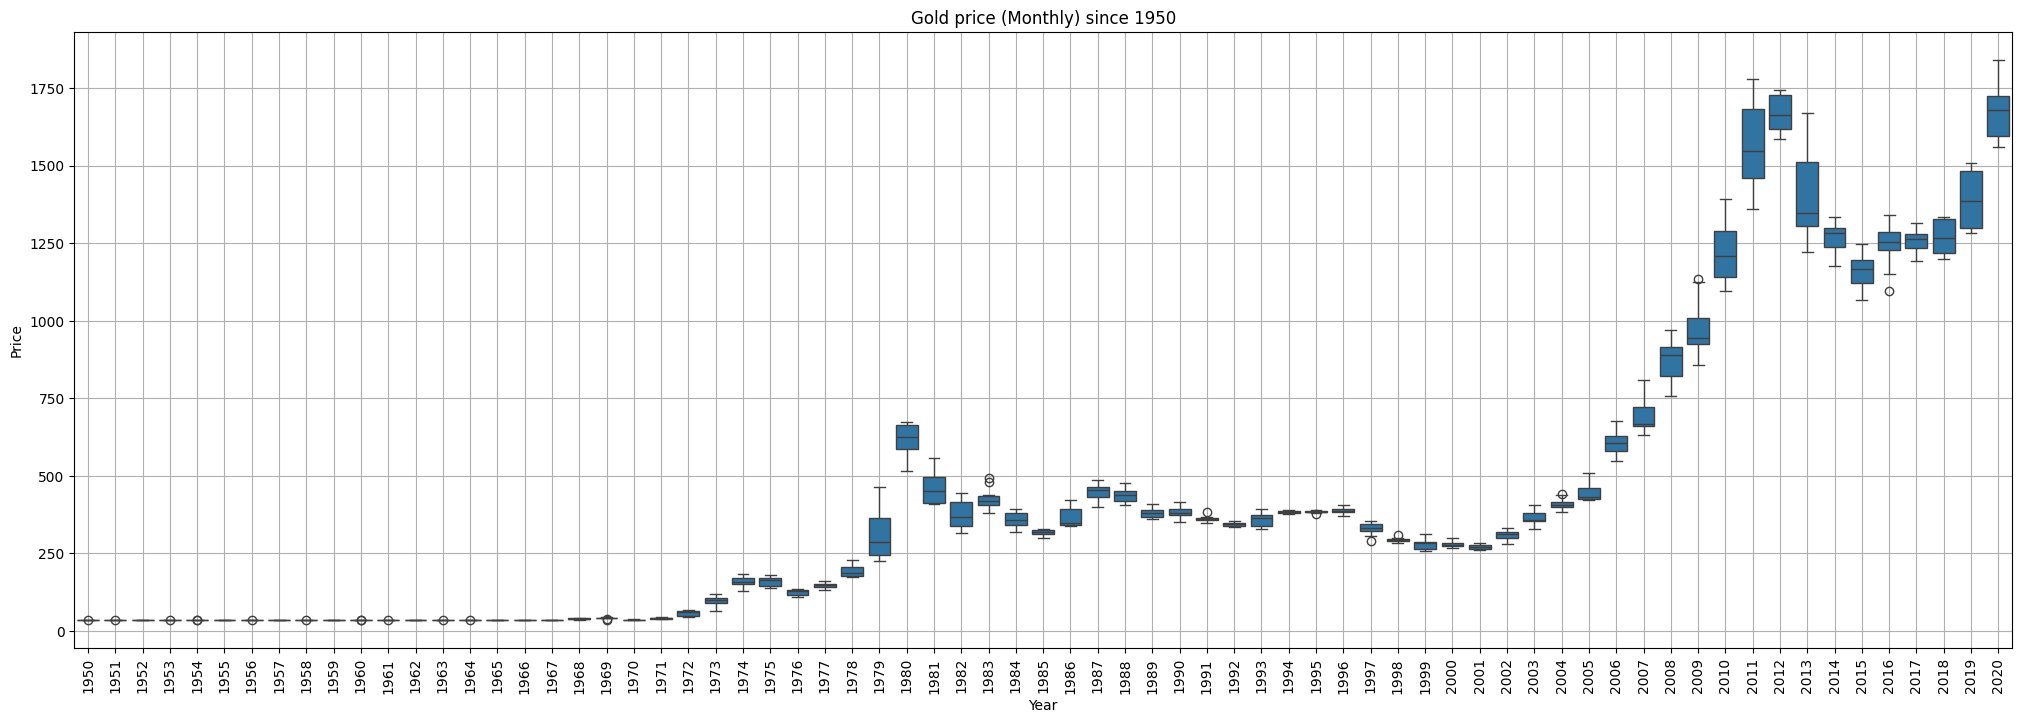

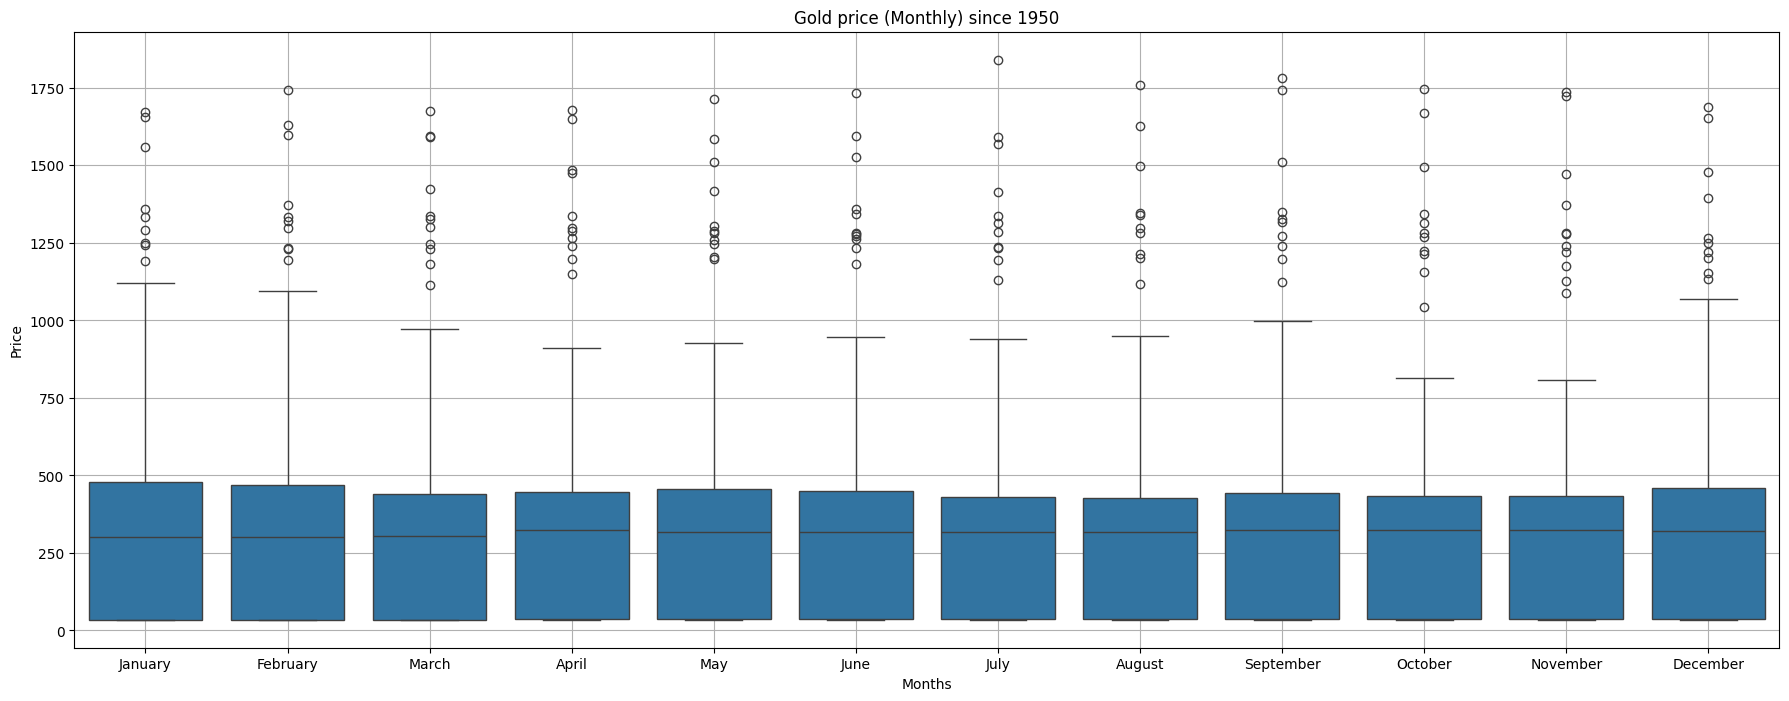

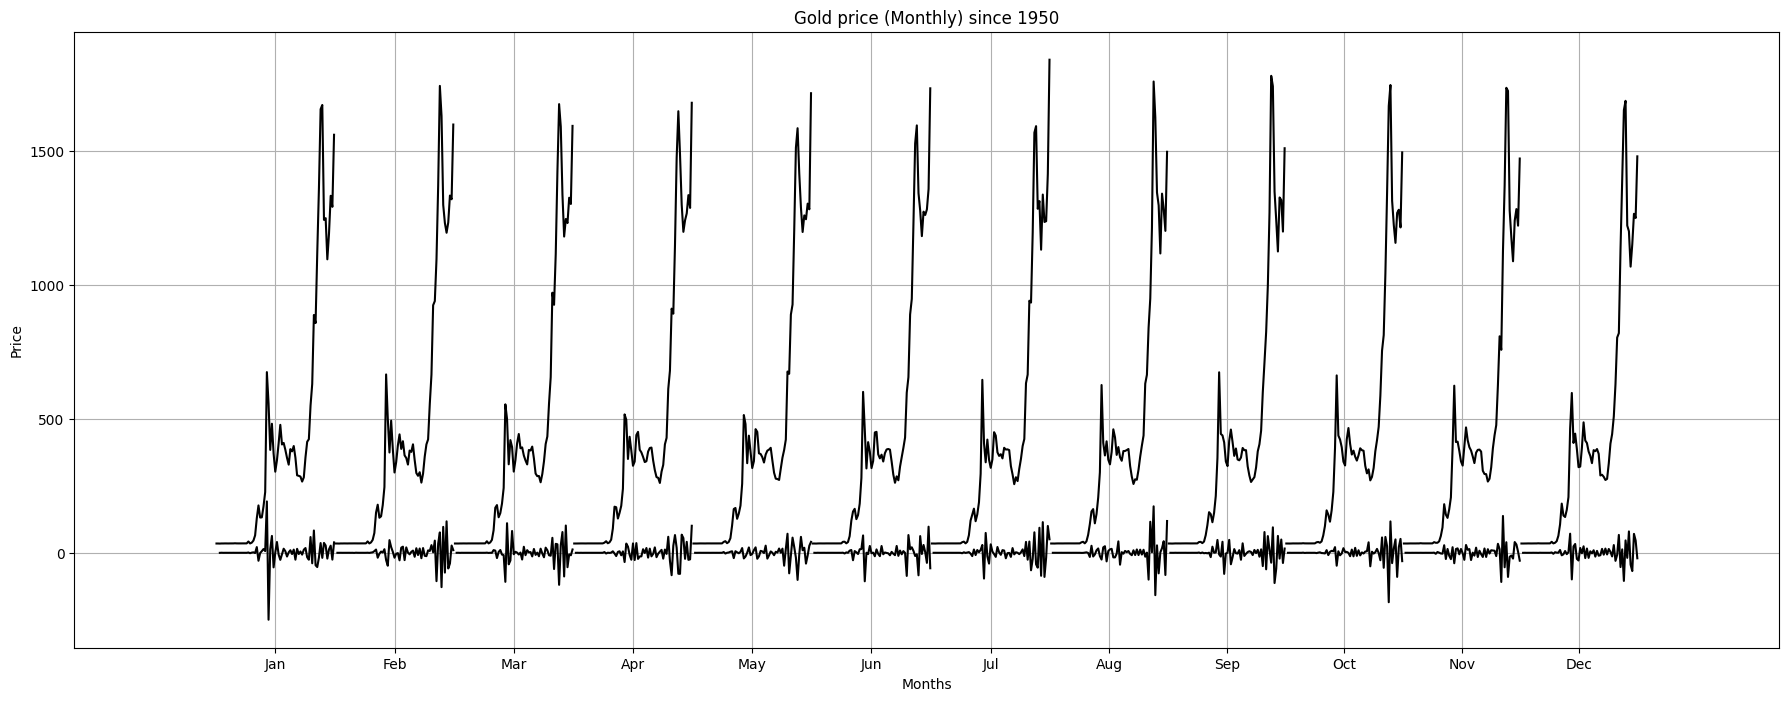

In [ ]:
##################6 (Added Seasonal Differencing)
# CHANGED: Apply proper differencing
print("\nStationarity Analysis after Differencing:")
df['Price_stationary'] = df['Price'].diff().diff(12).dropna()

def check_stationarity(series):
    # ADF Test
    adf = adfuller(series)
    print(f'ADF Statistic: {adf[0]:.4f}, p-value: {adf[1]:.4f}')

    # KPSS Test
    kpss_test = kpss(series, regression='ct')
    print(f'KPSS Statistic: {kpss_test[0]:.4f}, p-value: {kpss_test[1]:.4f}')

check_stationarity(df['Price_stationary'].dropna())

_, ax = plt.subplots(figsize=(25,8))
sns.boxplot(x = df.index.year,y = df.values[:,0],ax=ax)
plt.title("Gold price (Monthly) since 1950")
plt.xlabel("Year")
plt.ylabel("Price")
plt.xticks(rotation=90)
plt.grid();

_, ax = plt.subplots(figsize=(22,8))
sns.boxplot(x = df.index.month_name(),y = df.values[:,0],ax=ax)
plt.title("Gold price (Monthly) since 1950")
plt.xlabel("Months")
plt.ylabel("Price")
plt.grid();

from statsmodels.graphics.tsaplots import month_plot

fig, ax = plt.subplots(figsize=(22,8))

month_plot(df,ylabel='Gold price',ax=ax)
plt.title("Gold price (Monthly) since 1950")
plt.xlabel("Months")
plt.ylabel("Price")
plt.grid();

## 3.3 Time Aggregation Analysis
Analyzing data at different time scales can reveal different patterns and long-term trends. <a class="anchor" id="section3.3"></a>

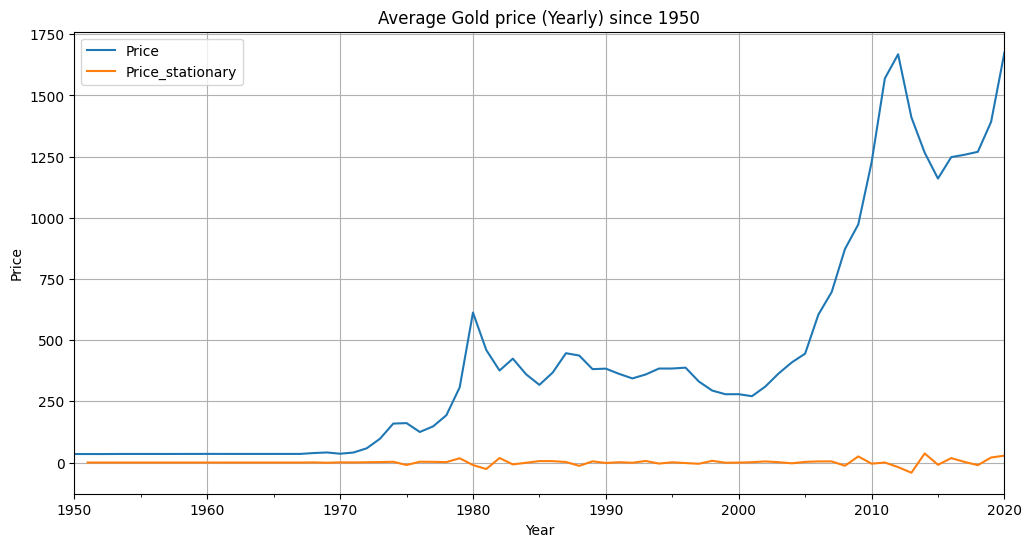

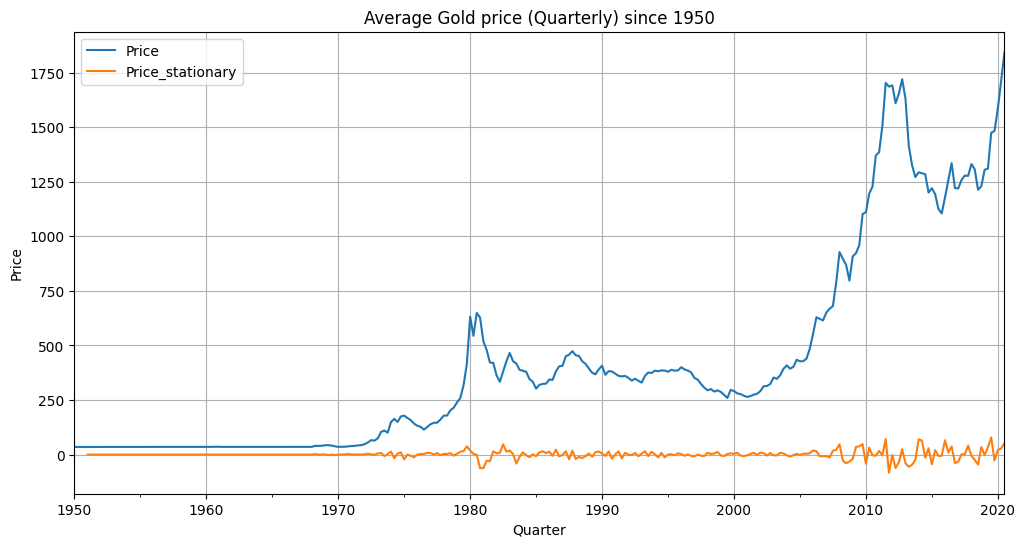

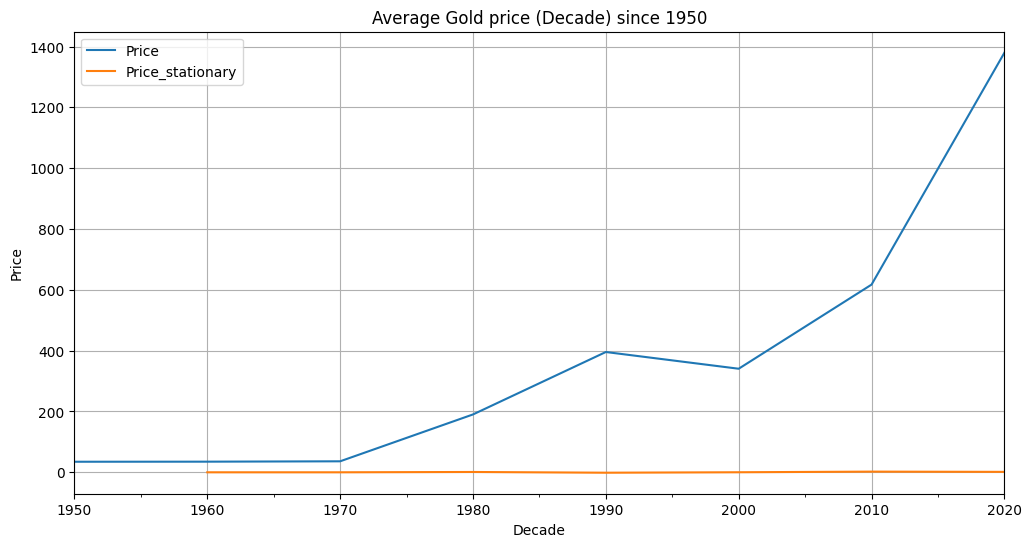

In [ ]:
# Average gold price per year trend since 1950
df_yearly_sum = df.resample('A').mean()  # 'A' represents annual frequency
df_yearly_sum.plot(figsize=(12,6))
plt.title("Average Gold price (Yearly) since 1950")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid()
plt.show()

# Average gold price per quarter trend since 1950
df_quarterly_sum = df.resample('Q').mean()  # 'Q' represents quarterly frequency
df_quarterly_sum.plot(figsize=(12,6))
plt.title("Average Gold price (Quarterly) since 1950")
plt.xlabel("Quarter")
plt.ylabel("Price")
plt.grid()
plt.show()

# Average gold price per decade trend since 1950
df_decade_sum = df.resample('10Y').mean()  # '10Y' represents decade frequency
df_decade_sum.plot(figsize=(12,6))
plt.title("Average Gold price (Decade) since 1950")
plt.xlabel("Decade")
plt.ylabel("Price")
plt.grid()
plt.show()



## 3.4 Analysis in Coefficient of variation
1. The coefficient of variation (CV) is a statistical measure of the relative dispersion of data points in a data series around the mean.
2. In finance, the coefficient of variation allows investors to determine how much volatility, or risk, is assumed in comparison to the amount of return expected from investments.
3. The lower the ratio of the standard deviation to mean return, the better risk-return trade-off.

Let us look at the CV values for each year in Gold price <a class="anchor" id="section3.4"></a>

In [ ]:
# Coefficient of variation in price
df_1 = df.groupby(df.index.year).agg(['mean', 'std'])['Price']  # Aggregate mean and std
df_1 = df_1.rename(columns={'mean': 'Mean', 'std': 'Std'})     # Rename columns
df_1['CoV_pct'] = ((df_1['Std'] / df_1['Mean']) * 100).round(2) # Calculate CoV
df_1.index.name = 'Year'
df_1 = df_1.reset_index()
df_1.head()

,Year,Mean,Std,CoV_pct
0,1950,34.729167,0.002887,0.01
1,1951,34.717500,0.020057,0.06
2,1952,34.628333,0.117538,0.34
3,1953,34.879167,0.056481,0.16
4,1954,35.020000,0.082792,0.24


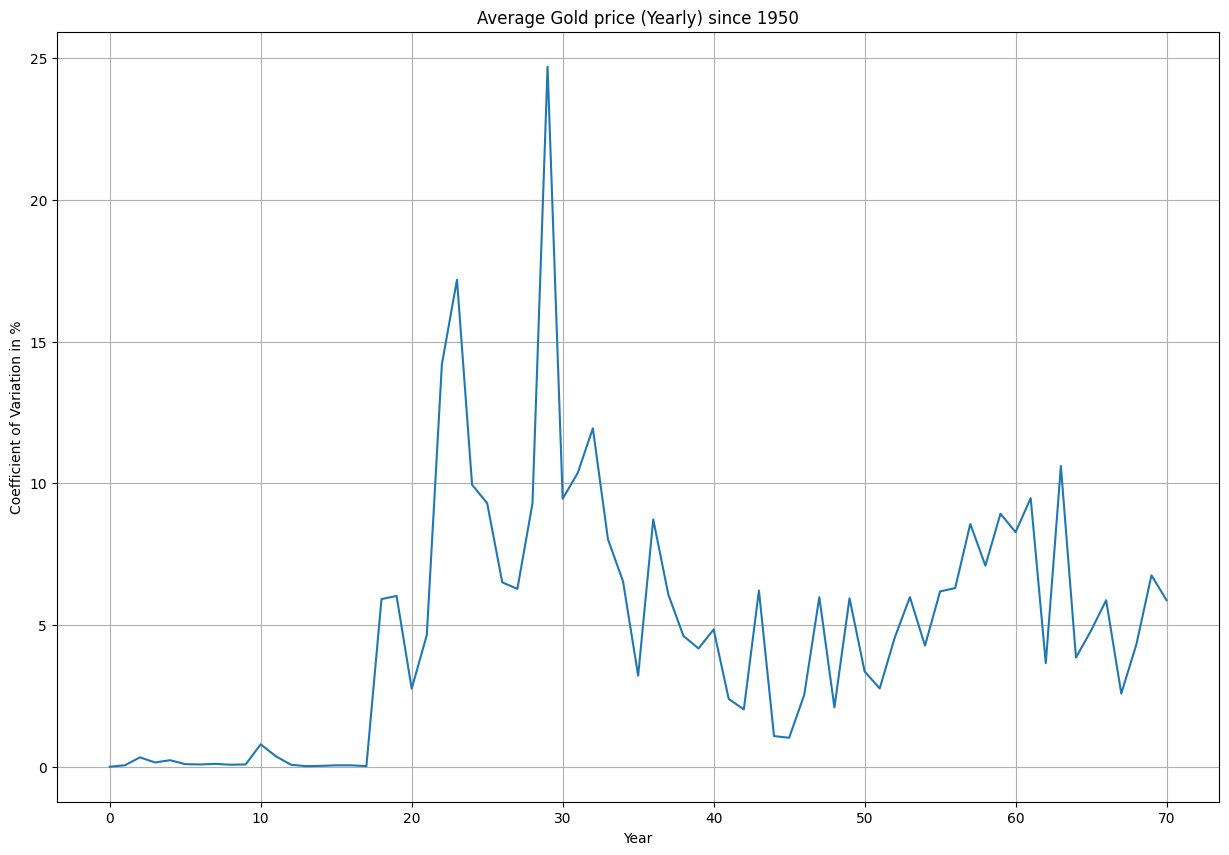

In [ ]:
# Average gold price per year trend since 1950
fig, ax = plt.subplots(figsize=(15,10))
df_1['CoV_pct'].plot();
plt.title("Average Gold price (Yearly) since 1950")
plt.xlabel("Year")
plt.ylabel("Coefficient of Variation in %")
plt.grid()

**Inference**

1. The CV value reached its highest in year 1978 near to 25%, which could have made the asset as highly risky
2. But in 2020, the CV value is closer to 5%, which makes the asset viable for good investment

# 4. Statistical Tests and Advanced Analysis <a class="anchor" id="section4"></a>

## 4.1 Stationarity Analysis
Stationarity is a fundamental concept in time series analysis. A stationary time series has constant statistical properties over time (mean, variance, and autocorrelation). Most time series models assume stationarity, so testing for it is crucial.

We use two complementary tests:
1. Augmented Dickey-Fuller (ADF) Test: Tests the null hypothesis that a unit root is present (series is non-stationary)

2. KPSS Test: Tests the null hypothesis that the series is stationary

If ADF p-value < 0.05: Reject null hypothesis → Series is stationary
If KPSS p-value > 0.05: Fail to reject null hypothesis → Series is stationary <a class="anchor" id="section4.1"></a>

In [ ]:
# Stationarity check function
def check_stationarity(series):
    """
    Perform stationarity tests (ADF and KPSS) on a time series

    Parameters:
    series (array-like): Time series data to test

    Returns:
    None: Prints test statistics and p-values
    """
    # ADF Test
    adf = adfuller(series)
    print(f'ADF Statistic: {adf[0]:.4f}, p-value: {adf[1]:.4f}')

    # KPSS Test
    kpss_test = kpss(series, regression='ct')
    print(f'KPSS Statistic: {kpss_test[0]:.4f}, p-value: {kpss_test[1]:.4f}')

# Check stationarity of original series
print("\nStationarity Analysis of Original Series:")
check_stationarity(df['Price'])

# Apply differencing to achieve stationarity
print("\nStationarity Analysis after Differencing:")
# First difference and seasonal difference (12 months)
df['Price_stationary'] = df['Price'].diff().diff(12).dropna()
check_stationarity(df['Price_stationary'].dropna())



Stationarity Analysis of Original Series:
ADF Statistic: 0.8143, p-value: 0.9919
KPSS Statistic: 0.5576, p-value: 0.0100

Stationarity Analysis after Differencing:
ADF Statistic: -6.8464, p-value: 0.0000
KPSS Statistic: 0.0245, p-value: 0.1000


## 4.2 Structural Break Analysis
Structural breaks are unexpected shifts in time series data that can indicate economic regime changes, policy shifts, or major events. Detecting these breaks is important for accurate modeling.

The CUSUM (Cumulative Sum) test detects structural breaks by analyzing the cumulative sum of recursive residuals <a class="anchor" id="section4.2"></a>



In [ ]:
# Structural break detection
# Use percentage changes instead of absolute differences for better scale-invariance
diff_series = df['Price'].pct_change().dropna()*100

# Require at least 5 years of data before allowing breaks
min_obs = 60  # 5 years * 12 months
if len(diff_series) > min_obs:
    # Create a constant for the regression model
    X = pd.DataFrame({'const': 1}, index=diff_series.index)
    ols_model = OLS(diff_series, X).fit()
    residuals = ols_model.resid

    # Use 5% significance level for the CUSUM test
    sup_b, pval, crit = breaks_cusumolsresid(residuals)
    print(f"\nStructural break p-value: {pval:.4f}")

    if pval < 0.05 and len(residuals) > min_obs:
        # Find the most likely break point
        break_idx = np.argmax(np.abs(sup_b)) + min_obs  # Ensure minimum history
        break_point = diff_series.index[break_idx]
        print(f"Significant structural break detected at: {break_point.date()}")
        # Create a dummy variable for the break (1 after break, 0 before)
        df['break_dummy'] = (df.index >= break_point).astype(int)

        # Visualize the structural break
        plt.figure(figsize=(12,6))
        df['Price'].plot()
        plt.axvline(break_point, color='r', linestyle='--', label='Structural Break')
        plt.title("Gold Prices with Structural Break")
        plt.legend()
        plt.grid()
        plt.show()
else:
    print("\nInsufficient data for structural break analysis")



Structural break p-value: 0.1912


## 4.3 Volatility Analysis with GARCH
GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models are used to estimate time-varying volatility in financial time series. They capture volatility clustering, where high volatility periods tend to be followed by high volatility periods.

The GARCH(1,1) model is defined as:

σ²ₜ = ω + α₁ε²ₜ₋₁ + β₁σ²ₜ₋₁

Where:

1. σ²ₜ is the conditional variance at time t

2. ω is a constant

3. α₁ is the coefficient for the previous squared error term

4. β₁ is the coefficient for the previous conditional variance <a class="anchor" id="section4.3"></a>



Iteration:      5,   Func. Count:     39,   Neg. LLF: 3107.8285543958045
Iteration:     10,   Func. Count:     74,   Neg. LLF: 2002.0393108044873
Iteration:     15,   Func. Count:    109,   Neg. LLF: 1917.9029401977964
Iteration:     20,   Func. Count:    144,   Neg. LLF: 1624.0806303218794
Iteration:     25,   Func. Count:    180,   Neg. LLF: 1588.39153870688
Iteration:     30,   Func. Count:    210,   Neg. LLF: 1587.1239846670278
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1587.1238184348188
            Iterations: 32
            Function evaluations: 223
            Gradient evaluations: 32

GARCH Model Summary:
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                        Price   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               

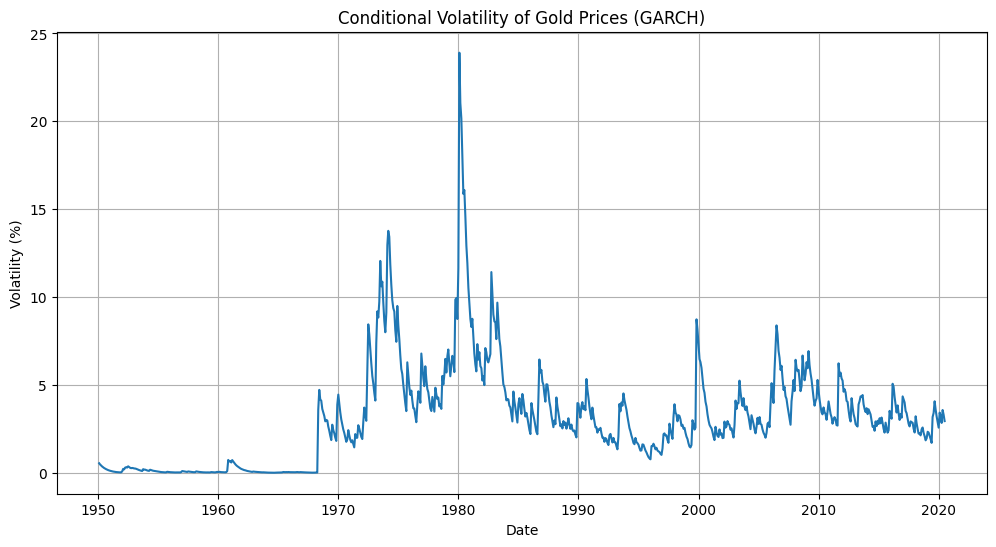

In [ ]:
# Calculate percentage returns for volatility analysis
returns = df['Price'].pct_change().dropna()*100

# GARCH(1,1) with student's t distribution for better fat-tail modeling
garch = arch_model(returns, vol='Garch', p=1, q=1, dist='StudentsT').fit(update_freq=5)
print("\nGARCH Model Summary:")
print(garch.summary())

# Plot the conditional volatility
plt.figure(figsize=(12,6))
plt.plot(garch.conditional_volatility)
plt.title("Conditional Volatility of Gold Prices (GARCH)")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid()
plt.show()


# 5. Data Preparation for Modeling
Before implementing forecasting models, we need to split our data into training and testing sets.
<a class="anchor" id="section5"></a>



Training set shape: (779, 2)
Test set shape: (55, 2)


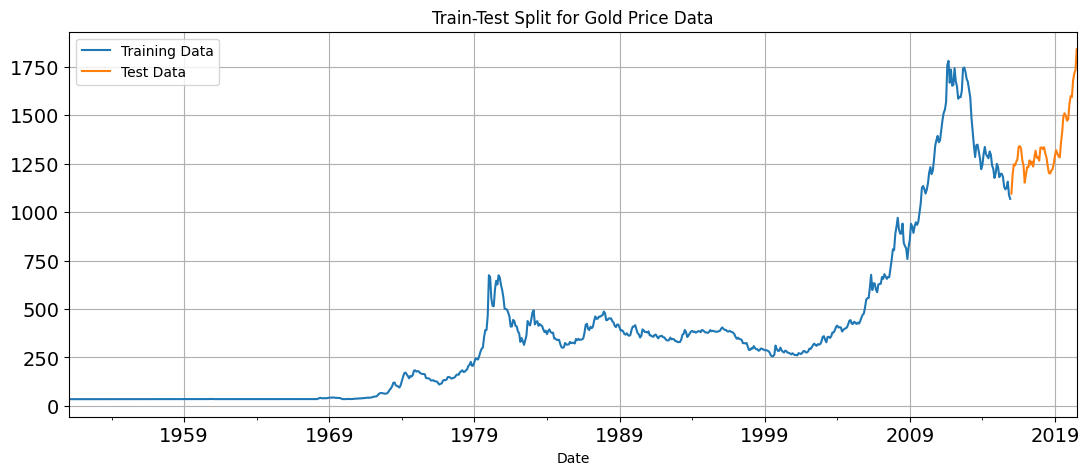

In [ ]:
# Train-test split based on time (data before and after 2015)
train = df[df.index.year <= 2015].dropna()
test = df[df.index.year > 2015].dropna()

print("Training set shape:", train.shape)
print("Test set shape:", test.shape)

# Visualize the train-test split
plt.figure(figsize=(13,5))
train['Price'].plot(fontsize=14, label='Training Data')
test['Price'].plot(fontsize=14, label='Test Data')
plt.grid(True)
plt.legend()
plt.title("Train-Test Split for Gold Price Data")
plt.show()


# 6. Basic Forecasting Models <a class="anchor" id="section6"></a>

## 6.1 Linear Regression Model
Linear Regression models the relationship between dependent and independent variables. For time series forecasting, we use time as a predictor along with seasonal indicators (months).

The equation is: Price = β₀ + β₁(time) + β₂(month₂) + ... + β₁₂(month₁₂) + ε <a class="anchor" id="section6.1"></a>

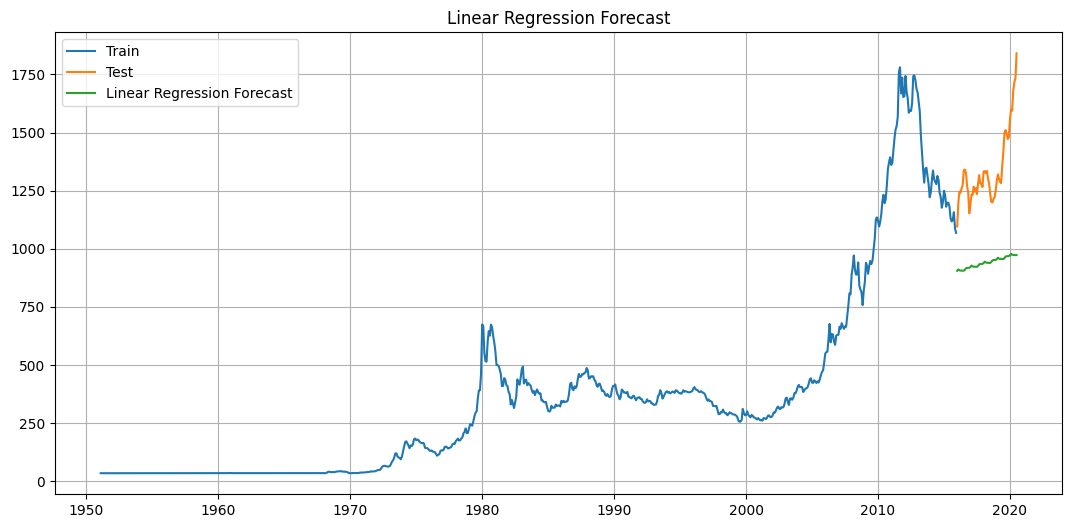

For Linear Regression forecast on the Test Data, MAPE is 29.140%


In [ ]:
# Create time features for Linear Regression
LR_train = train.copy()
LR_test = test.copy()

# Add month column (1-12 for Jan-Dec)
LR_train['month'] = LR_train.index.month
LR_test['month'] = LR_test.index.month

# Create scaled time feature (months since start of training data)
LR_train['time'] = (LR_train.index - LR_train.index[0]).days / 30
LR_test['time'] = (LR_test.index - LR_train.index[0]).days / 30

# Convert month to dummy variables (one-hot encoding)
LR_train = pd.get_dummies(LR_train, columns=['month'], prefix='month', drop_first=True)
LR_test = pd.get_dummies(LR_test, columns=['month'], prefix='month', drop_first=True)

# Ensure test set has all columns from training set
train_cols = list(LR_train.columns)
test_cols = list(LR_test.columns)

# Add missing columns to test set with zeros
for col in train_cols:
    if col not in test_cols:
        LR_test[col] = 0

# Ensure test set only has columns from training set
LR_test = LR_test[train_cols]

# Train Linear Regression model
lr = LinearRegression()
# Remove target variable and differenced series from predictors
lr.fit(LR_train.drop(columns=['Price', 'Price_stationary']), LR_train['Price'])

# Generate predictions on test set
LR_test['forecast'] = lr.predict(LR_test.drop(columns=['Price', 'Price_stationary']))

# Plot Linear Regression results
plt.figure(figsize=(13,6))
plt.plot(train['Price'], label='Train')
plt.plot(test['Price'], label='Test')
plt.plot(LR_test.index, LR_test['forecast'], label='Linear Regression Forecast')
plt.legend(loc='best')
plt.title("Linear Regression Forecast")
plt.grid()
plt.show()

# Calculate MAPE for evaluation
mape_lr = mape(test['Price'].values, LR_test['forecast'].values)
print(f"For Linear Regression forecast on the Test Data, MAPE is {mape_lr:.3f}%")

# Store results in DataFrame
results = pd.DataFrame({'Test MAPE (%)': [mape_lr]}, index=['LinearRegression'])


In [ ]:
# Get MAPE of the model

mape_model1_test = mape(test['Price'].values,LR_test['forecast'].values)
print("For Linear Regression on the Test Data,  MAPE is %3.3f" %(mape_model1_test),"%")

For Linear Regression on the Test Data,  MAPE is 29.140 %


In [ ]:
results = pd.DataFrame({'Test MAPE (%)': [mape_lr]}, index=['LinearRegression'])

## 6.2 Naive Forecast Model
The Naive Forecast simply uses the last observed value as the prediction for all future periods. This serves as a baseline benchmark for more sophisticated models. <a class="anchor" id="section6.2"></a>

In [ ]:
Naive_train = train.copy()
Naive_test = test.copy()

In [ ]:
# Naive Model implementation
Naive_train = train.copy()
Naive_test = test.copy()

# Set all forecast values to the last observed training value
Naive_test['Naive'] = np.asarray(train['Price'])[len(np.asarray(train['Price']))-1]

# CHANGED: Reset index and display Date, Naive, and Price in a single line
Naive_test.reset_index()[['Date', 'Naive', 'Price']].head()

,Date,Naive,Price
0,2016-01-01,1068.317,1095.655
1,2016-02-01,1068.317,1194.893
2,2016-03-01,1068.317,1246.312
3,2016-04-01,1068.317,1241.452
4,2016-05-01,1068.317,1259.755


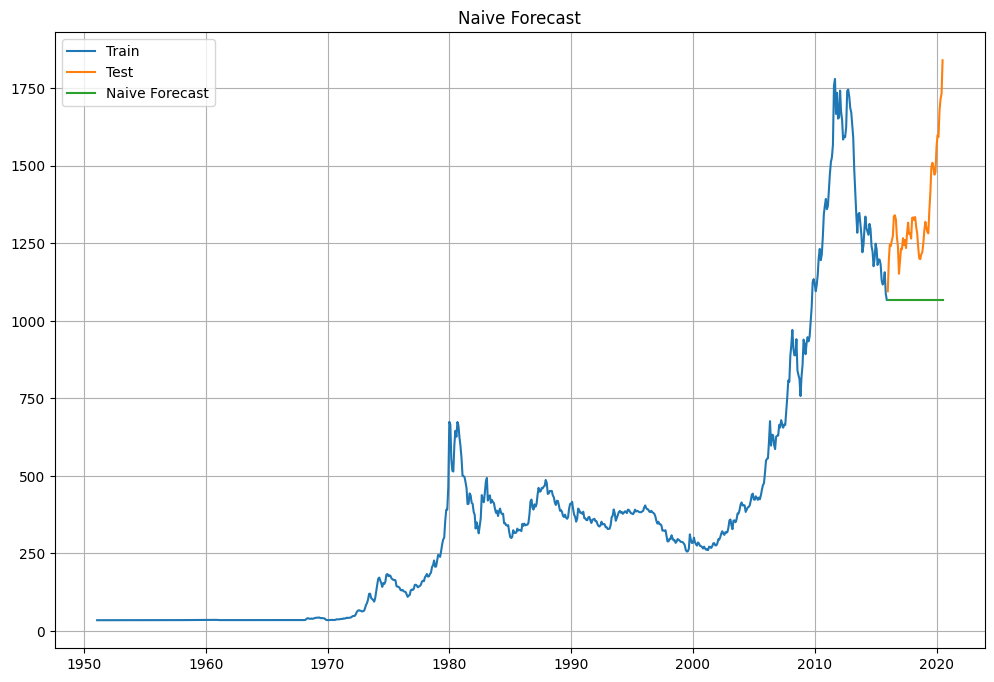

For Naive forecast on the Test Data, MAPE is 19.380%


In [ ]:
# Naive Model implementation
Naive_train = train.copy()
Naive_test = test.copy()
# Set all forecast values to the last observed training value
Naive_test['Naive'] = np.asarray(train['Price'])[len(np.asarray(train['Price']))-1]

# Plot Naive results
plt.figure(figsize=(12,8))
plt.plot(Naive_train['Price'], label='Train')
plt.plot(test['Price'], label='Test')
plt.plot(Naive_test.index, Naive_test['Naive'], label='Naive Forecast')
plt.legend(loc='best')
plt.title("Naive Forecast")
plt.grid()
plt.show()

# Calculate MAPE
mape_naive = mape(test['Price'].values, Naive_test['Naive'].values)
print(f"For Naive forecast on the Test Data, MAPE is {mape_naive:.3f}%")

# Add to results
resultsDf_2 = pd.DataFrame({'Test MAPE (%)': [mape_naive]}, index=['NaiveModel'])
results = pd.concat([results, resultsDf_2])


In [ ]:
# Get MAPE of the model

mape_model2_test = mape(test['Price'].values,Naive_test['Naive'].values)
print("For Naive forecast on the Test Data,  MAPE is %3.3f" %(mape_model2_test),"%")

For Naive forecast on the Test Data,  MAPE is 19.380 %


In [ ]:
results.loc['NaiveModel'] = [mape_model2_test]
results

,Test MAPE (%)
LinearRegression,29.14
NaiveModel,19.38


## 6.3 Simple Average Model
The Simple Average Model uses the average of all historical values as the forecast for all future periods. This is another baseline model. <a class="anchor" id="section6.3"></a>

In [ ]:
SimpleAvg_train = train.copy()
SimpleAvg_test = test.copy()
SimpleAvg_test['mean_forecast'] = train['Price'].mean()

SimpleAvg_test.reset_index()[['Date', 'Price', 'Price_stationary', 'mean_forecast']].head()

,Date,Price,Price_stationary,mean_forecast
0,2016-01-01,1095.655,-21.555,357.672693
1,2016-02-01,1194.893,117.471,357.672693
2,2016-03-01,1246.312,101.883,357.672693
3,2016-04-01,1241.452,-22.477,357.672693
4,2016-05-01,1259.755,18.872,357.672693


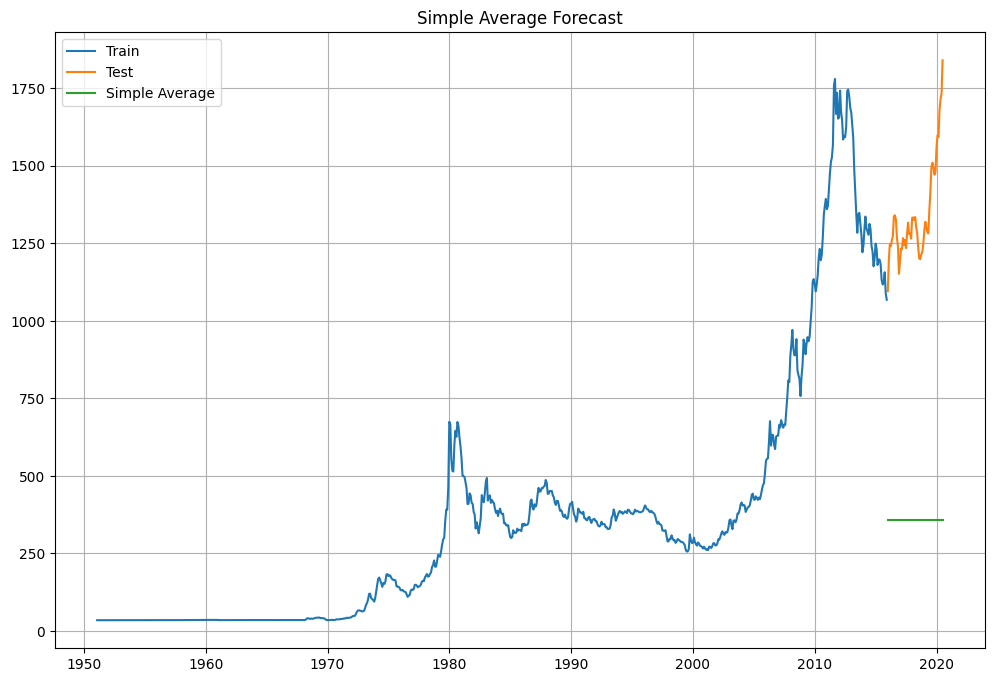

For Simple Average forecast on the Test Data, MAPE is 73.010%


In [ ]:
# Simple Average Model implementation
SimpleAvg_train = train.copy()
SimpleAvg_test = test.copy()
# Set all forecast values to the mean of training data
SimpleAvg_test['mean_forecast'] = train['Price'].mean()

# Plot Simple Average results
plt.figure(figsize=(12,8))
plt.plot(SimpleAvg_train['Price'], label='Train')
plt.plot(SimpleAvg_test['Price'], label='Test')
plt.plot(SimpleAvg_test.index, SimpleAvg_test['mean_forecast'], label='Simple Average')
plt.legend(loc='best')
plt.title("Simple Average Forecast")
plt.grid()
plt.show()

# Calculate MAPE
mape_avg = mape(test['Price'].values, SimpleAvg_test['mean_forecast'].values)
print(f"For Simple Average forecast on the Test Data, MAPE is {mape_avg:.3f}%")

# Add to results
resultsDf_3 = pd.DataFrame({'Test MAPE (%)': [mape_avg]}, index=['SimpleAverageModel'])
results = pd.concat([results, resultsDf_3])


In [ ]:
## Test Data - MAPE

mape_model3_test = mape(test['Price'].values,SimpleAvg_test['mean_forecast'].values)
print("For Simple Average forecast on the Test Data,  MAPE is %3.3f" %(mape_model3_test),"%")

For Simple Average forecast on the Test Data,  MAPE is 73.010 %


In [ ]:
resultsDf_3 = pd.DataFrame({'Test MAPE (%)': [mape_model3_test]},index=['SimpleAverageModel'])

results = pd.concat([results, resultsDf_3])
results = results.drop_duplicates()
results

,Test MAPE (%)
LinearRegression,29.14
NaiveModel,19.38
SimpleAverageModel,73.01


# 7. Moving Average Models
Moving Average (MA) models use the average of n previous observations to forecast the next value. They smooth out short-term fluctuations and highlight longer-term trends.

The forecast equation is:

ŷₜ = (yₜ₋₁ + yₜ₋₂ + ... + yₜ₋ₙ) / n <a class="anchor" id="section7"></a>

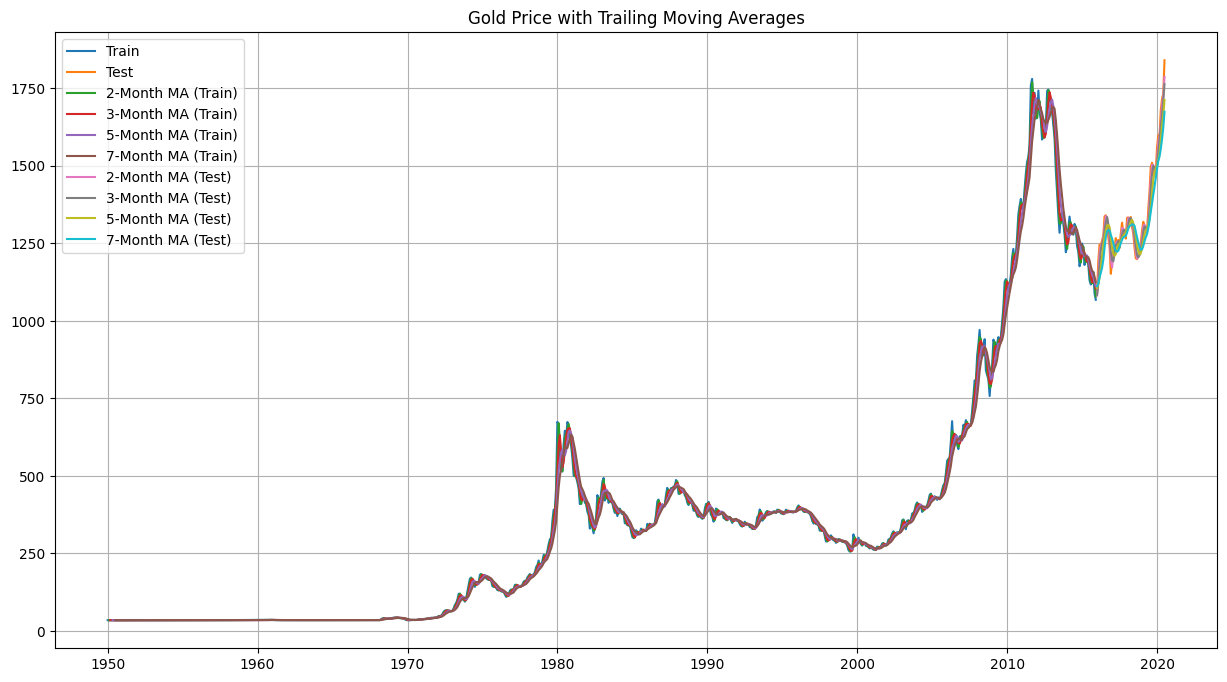

For 2-month Moving Average forecast, MAPE is 1.230%
For 3-month Moving Average forecast, MAPE is 2.050%
For 5-month Moving Average forecast, MAPE is 3.330%
For 7-month Moving Average forecast, MAPE is 4.180%


In [ ]:
# Moving Average Models implementation
Mvg_Avg = df.copy()
# Calculate moving averages with different window sizes
Mvg_Avg['Trailing_2'] = Mvg_Avg['Price'].rolling(2).mean()  # 2-month window
Mvg_Avg['Trailing_3'] = Mvg_Avg['Price'].rolling(3).mean()  # 3-month window
Mvg_Avg['Trailing_5'] = Mvg_Avg['Price'].rolling(5).mean()  # 5-month window
Mvg_Avg['Trailing_7'] = Mvg_Avg['Price'].rolling(7).mean()  # 7-month window

# Creating train and test set for moving averages
trailing_Mvg_Avg_train = Mvg_Avg[Mvg_Avg.index.year <= 2015]
trailing_Mvg_Avg_test = Mvg_Avg[Mvg_Avg.index.year > 2015]

# Plot moving averages on train/test data
plt.figure(figsize=(15,8))
plt.plot(trailing_Mvg_Avg_train['Price'], label='Train')
plt.plot(trailing_Mvg_Avg_test['Price'], label='Test')
plt.plot(trailing_Mvg_Avg_train['Trailing_2'], label='2-Month MA (Train)')
plt.plot(trailing_Mvg_Avg_train['Trailing_3'], label='3-Month MA (Train)')
plt.plot(trailing_Mvg_Avg_train['Trailing_5'], label='5-Month MA (Train)')
plt.plot(trailing_Mvg_Avg_train['Trailing_7'], label='7-Month MA (Train)')
plt.plot(trailing_Mvg_Avg_test['Trailing_2'], label='2-Month MA (Test)')
plt.plot(trailing_Mvg_Avg_test['Trailing_3'], label='3-Month MA (Test)')
plt.plot(trailing_Mvg_Avg_test['Trailing_5'], label='5-Month MA (Test)')
plt.plot(trailing_Mvg_Avg_test['Trailing_7'], label='7-Month MA (Test)')
plt.legend(loc='best')
plt.title("Gold Price with Trailing Moving Averages")
plt.grid()
plt.show()

# Calculate MAPEs for different moving averages
for period in [2, 3, 5, 7]:
    ma_mape = mape(test['Price'].values, trailing_Mvg_Avg_test[f'Trailing_{period}'].values)
    print(f"For {period}-month Moving Average forecast, MAPE is {ma_mape:.3f}%")

    # Add to results DataFrame
    results = pd.concat([results,
                         pd.DataFrame({'Test MAPE (%)': [ma_mape]},
                                     index=[f'{period}pointMA'])])


In [ ]:
# Calculate MAPEs for different moving averages and store them in variables
mape_model4_test_2 = mape(test['Price'].values, trailing_Mvg_Avg_test['Trailing_2'].values)
mape_model4_test_3 = mape(test['Price'].values, trailing_Mvg_Avg_test['Trailing_3'].values)
mape_model4_test_5 = mape(test['Price'].values, trailing_Mvg_Avg_test['Trailing_5'].values)
mape_model4_test_7 = mape(test['Price'].values, trailing_Mvg_Avg_test['Trailing_7'].values)

# Add results to DataFrame for later comparison
resultsDf_4 = pd.DataFrame({'Test MAPE (%)': [mape_model4_test_2, mape_model4_test_3,
                                              mape_model4_test_5, mape_model4_test_7]},
                           index=['2pointMA', '3pointMA',
                                   '5pointMA', '7pointMA'])

results = pd.concat([results, resultsDf_4])
results = results.drop_duplicates()
results

,Test MAPE (%)
LinearRegression,29.14
NaiveModel,19.38
SimpleAverageModel,73.01
2pointMA,1.23
3pointMA,2.05
5pointMA,3.33
7pointMA,4.18


# 8. Advanced Time Series Models <a class="anchor" id="section4"></a>

## 8.1 SARIMA Model
SARIMA (Seasonal AutoRegressive Integrated Moving Average) extends ARIMA to handle seasonal data. It's specified as SARIMA(p,d,q)(P,D,Q)s, where:

- p = order of non-seasonal autoregression

- d = order of non-seasonal differencing

- q = order of non-seasonal moving average

- P = order of seasonal autoregression

- D = order of seasonal differencing

- Q = order of seasonal moving average

- s = time span of seasonality

SARIMA can capture complex patterns in economic time series with both trend and seasonality.

Here we have implemented Rolling Window + SARIMA

# Rolling Window SARIMA (Walk-Forward Forecasting)

The Rolling Window SARIMA approach retrains the SARIMA model at each time step using all available data up to that point, then forecasts the next value. This process mimics real-world forecasting, where new data becomes available sequentially. It is more robust than static (batch) training for non-stationary or evolving time series.

- **SARIMA**: Seasonal AutoRegressive Integrated Moving Average, suitable for data with both trend and seasonality.
- **Walk-forward**: At each test step, the model is fit on all data observed so far, then predicts the next point.
- **Advantage**: Adapts to changes, incorporates new patterns, and provides realistic error estimates.<a class="anchor" id="section8.1"></a>


Implementing Rolling Window SARIMA Forecasting...
Predicting 2016-01-01: predicted=1088.83, actual=1095.65
Predicting 2016-02-01: predicted=1091.89, actual=1194.89
Predicting 2016-03-01: predicted=1214.49, actual=1246.31
Predicting 2016-04-01: predicted=1239.78, actual=1241.45
Predicting 2016-05-01: predicted=1244.82, actual=1259.76
Predicting 2016-06-01: predicted=1260.06, actual=1273.58
Predicting 2016-07-01: predicted=1274.77, actual=1337.43
Predicting 2016-08-01: predicted=1353.82, actual=1340.86
Predicting 2016-09-01: predicted=1338.15, actual=1326.62
Predicting 2016-10-01: predicted=1331.33, actual=1268.93
Predicting 2016-11-01: predicted=1252.46, actual=1240.29
Predicting 2016-12-01: predicted=1246.06, actual=1152.16
Predicting 2017-01-01: predicted=1134.91, actual=1192.65
Predicting 2017-02-01: predicted=1221.57, actual=1233.39
Predicting 2017-03-01: predicted=1222.44, actual=1231.06
Predicting 2017-04-01: predicted=1235.34, actual=1267.15
Predicting 2017-05-01: predicted=1270

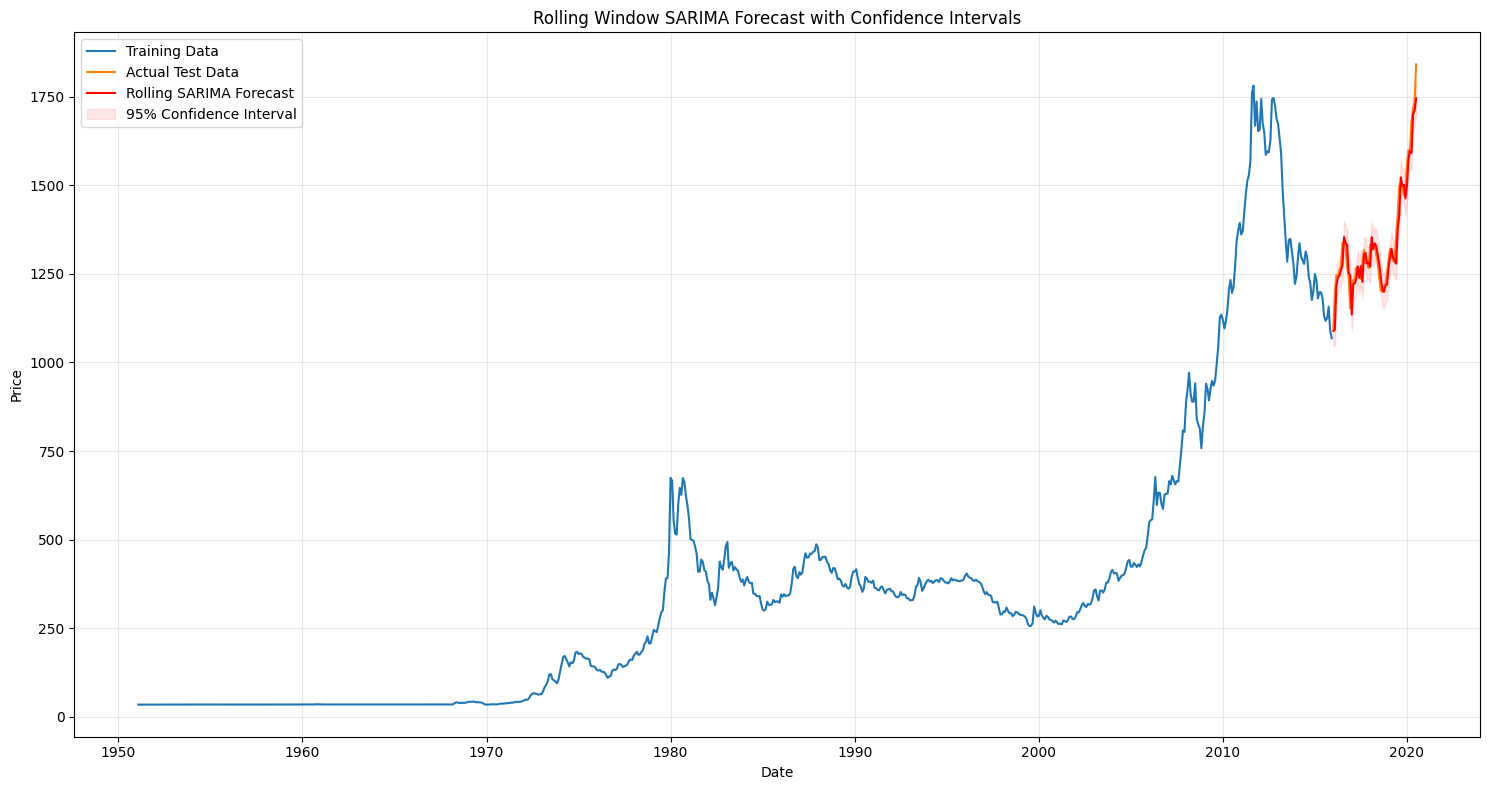

In [ ]:
# ROLLING WINDOW SARIMA IMPLEMENTATION
print("\nImplementing Rolling Window SARIMA Forecasting...")

# Define SARIMA order parameters
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

# Initialize containers for actual values and predictions
history = train['Price'].copy()
predictions = pd.Series(index=test.index)
confidence_intervals = pd.DataFrame(index=test.index)

# Walk-forward validation for SARIMA
for i in range(len(test)):
    # Get the current test timestamp
    t = test.index[i]

    # Train SARIMA model with all available history
    if 'break_dummy' in df.columns:
        # If structural break dummy exists, use it as exogenous variable
        history_exog = df.loc[history.index, 'break_dummy']
        t_exog = df.loc[t:t, 'break_dummy']

        model = SARIMAX(history,
                        exog=history_exog,
                        order=order,
                        seasonal_order=seasonal_order)
        model_fit = model.fit(disp=False)

        # Make one-step ahead forecast
        forecast = model_fit.get_forecast(steps=1, exog=t_exog)
    else:
        # Train model without exogenous variables
        model = SARIMAX(history,
                        order=order,
                        seasonal_order=seasonal_order)
        model_fit = model.fit(disp=False)

        # Make one-step ahead forecast
        forecast = model_fit.get_forecast(steps=1)

    # Extract prediction and confidence interval
    pred_mean = forecast.predicted_mean[0]
    pred_ci = forecast.conf_int()

    # Store prediction and confidence interval
    predictions[t] = pred_mean
    confidence_intervals.loc[t, 'lower'] = pred_ci.iloc[0, 0]
    confidence_intervals.loc[t, 'upper'] = pred_ci.iloc[0, 1]

    # Update history with actual value for next iteration
    history = pd.concat([history, test.loc[t:t, 'Price']])

    # Print progress
    print(f"Predicting {t.date()}: predicted={pred_mean:.2f}, actual={test.loc[t, 'Price']:.2f}")

# Calculate performance metrics
sarima_mape = mape(test['Price'].values, predictions.values)
sarima_rmse = np.sqrt(mean_squared_error(test['Price'].values, predictions.values))

print(f"\nRolling SARIMA Test MAPE: {sarima_mape:.2f}%")
print(f"Rolling SARIMA Test RMSE: {sarima_rmse:.2f}")

# Plot rolling SARIMA results with confidence intervals
plt.figure(figsize=(15, 8))
plt.plot(train['Price'], label='Training Data')
plt.plot(test['Price'], label='Actual Test Data')
plt.plot(predictions, label='Rolling SARIMA Forecast', color='red')
plt.fill_between(confidence_intervals.index,
                 confidence_intervals['lower'],
                 confidence_intervals['upper'],
                 color='red', alpha=0.1, label='95% Confidence Interval')
plt.title('Rolling Window SARIMA Forecast with Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Add results to overall comparison
rolling_sarima_results = pd.DataFrame(
    {'Test MAPE (%)': [sarima_mape]},
    index=['Rolling SARIMA']
)
results = pd.concat([results, rolling_sarima_results])


## 8.2 Holt-Winters Exponential Smoothing
The Holt-Winters method is a powerful forecasting technique designed for time series data that exhibits both trend and seasonality. It extends simple exponential smoothing by explicitly modeling the level, trend, and seasonal components.

Key Components:
Level ($\ell_t$): The baseline value of the series at time $t$.

Trend ($b_t$): The slope or rate of change at time $t$.

Seasonality ($s_t$): The repeating short-term cycle in the data (e.g., monthly, quarterly).

Types of Holt-Winters Models:
Additive: Use when seasonal variations are roughly constant throughout the series.

Multiplicative: Use when seasonal variations increase or decrease proportionally with the level.

Additive Holt-Winters Model Equations
Let:

- $y_t$: Actual value at time $t$

- $\alpha, \beta, \gamma$ : Smoothing parameters for level, trend, and seasonality ($0<\alpha,\beta,\gamma < 1$)

- $m$: Number of periods in one season (e.g., 12 for monthly data with yearly seasonality)

- $h$: Forecast horizon

- $k$: Integer such that $h = qm + r \Rightarrow$ we use $s_{t + h - m(k+1)}$ for the forecast

## 📊 Holt-Winters Additive Model Equations (with Subscripts)

Let:  
- $y_t$: Actual value at time $t$  
- $\ell_t$: Level at time $t$  
- $b_t$: Trend at time $t$  
- $s_t$: Seasonality at time $t$  
- $\alpha, \beta, \gamma$: Smoothing parameters for level, trend, and seasonality respectively  
- $m$: Number of periods per season  
- $h$: Forecast horizon  
- $\hat{y}_{t+h}$: Forecast $h$ steps ahead from $t$  

---

### 📌 Level Equation:
$ \ell_t = \alpha (y_t - s_{t - m}) + (1 - \alpha)(\ell_{t - 1} + b_{t - 1}) $

---

### 📌 Trend Equation:
$ b_t = \beta (\ell_t - \ell_{t - 1}) + (1 - \beta) b_{t - 1} $

---

### 📌 Seasonality Equation:
$ s_t = \gamma (y_t - \ell_{t - 1} - b_{t - 1}) + (1 - \gamma) s_{t - m} $

---

### 📌 Forecast Equation:
$ \hat{y}_{t+h} = \ell_t + h b_t + s_{t + h - m(k+1)} $

---

> 🔁 The term $s_{t + h - m(k+1)}$ ensures seasonal indexing wraps correctly over time.

Parameter Selection:

Parameters $\alpha$, $\beta$, and $\gamma$ are usually optimized automatically (e.g., via grid search or built-in optimization) to minimize forecast error.

Advantages:

- Handles both trend and seasonality.

- Suitable for short- and medium-term forecasting.

- Widely used in business, finance, and economics.

## 📊Rolling Window Holt-Winters Evaluation
Rolling window evaluation is a robust approach to assess time series model performance over time, mimicking real-world forecasting conditions.

## Concept:

Instead of using a single train-test split, the model is retrained on a moving window and tested on the next immediate period.

This emulates real-time forecasting, where only past data is available.

##Procedure:
Set window size (e.g., 60 months = 5 years).

For each rolling window:

1. Train the Holt-Winters model on the window.

2. Forecast the next period (e.g., 12 months).

3. Compute error metrics (e.g., MAPE) against actuals.

4. Slide the window forward (e.g., by 12 months) and repeat.

5. Aggregate forecast errors across all windows.

## Benefits:
- Detects time-dependent accuracy patterns.

- Reveals robustness to structural changes or regime shifts.

- Provides a realistic estimate of expected forecasting performance.
<a class="anchor" id="section8.2"></a>

Predicting 2016-01-01: predicted=1062.94, actual=1095.65
Predicting 2016-02-01: predicted=1089.85, actual=1194.89
Predicting 2016-03-01: predicted=1186.84, actual=1246.31
Predicting 2016-04-01: predicted=1243.22, actual=1241.45
Predicting 2016-05-01: predicted=1241.77, actual=1259.76
Predicting 2016-06-01: predicted=1257.48, actual=1273.58
Predicting 2016-07-01: predicted=1273.16, actual=1337.43
Predicting 2016-08-01: predicted=1341.45, actual=1340.86
Predicting 2016-09-01: predicted=1347.40, actual=1326.62
Predicting 2016-10-01: predicted=1328.25, actual=1268.93
Predicting 2016-11-01: predicted=1266.89, actual=1240.29
Predicting 2016-12-01: predicted=1238.18, actual=1152.16
Predicting 2017-01-01: predicted=1153.79, actual=1192.65
Predicting 2017-02-01: predicted=1193.33, actual=1233.39
Predicting 2017-03-01: predicted=1226.56, actual=1231.06
Predicting 2017-04-01: predicted=1226.96, actual=1267.15
Predicting 2017-05-01: predicted=1267.88, actual=1245.25
Predicting 2017-06-01: predicte

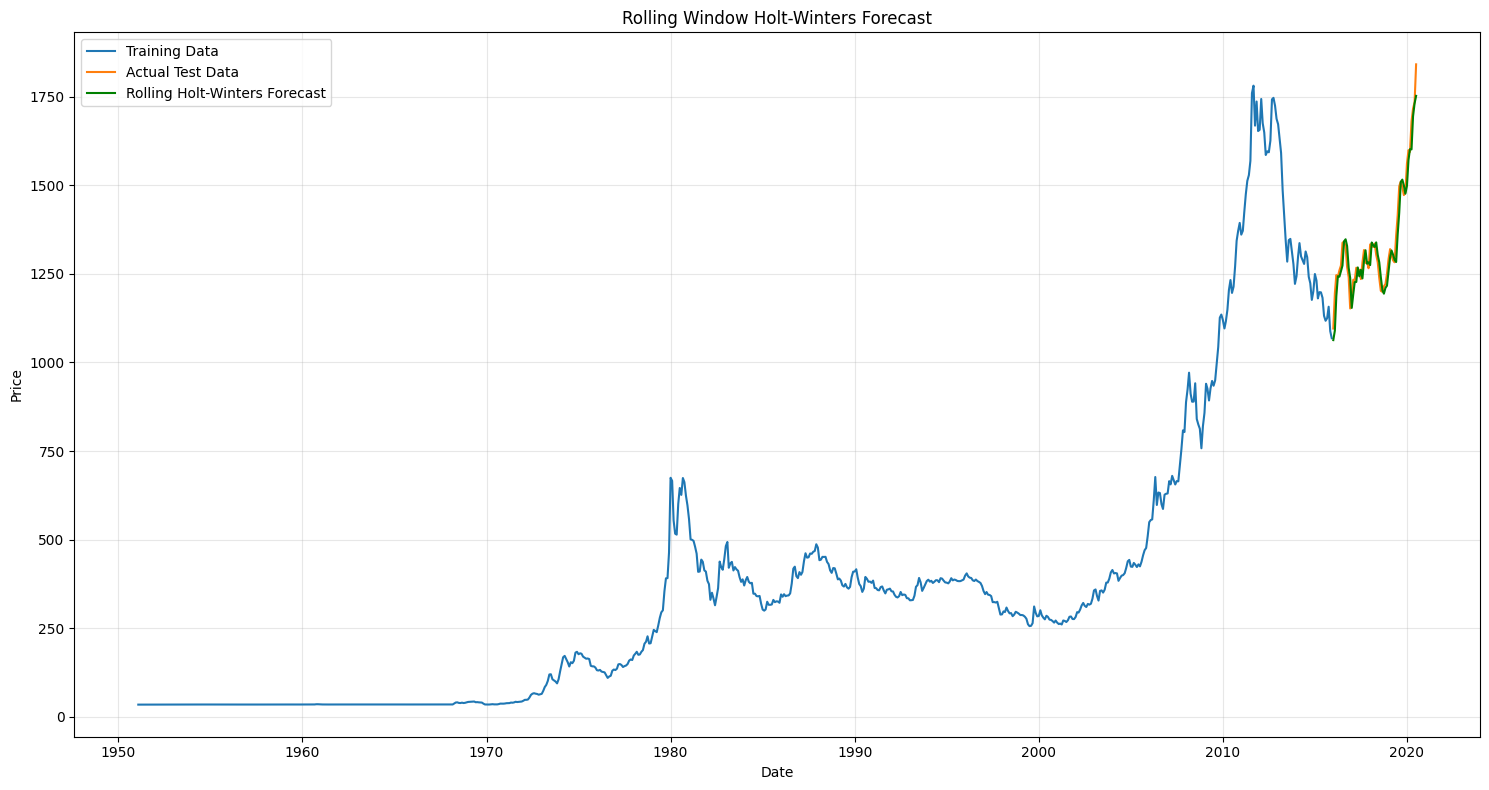

In [ ]:
# --- Rolling Window Holt-Winters (Exponential Smoothing) Forecast ---
from statsmodels.tsa.holtwinters import ExponentialSmoothing

history = train['Price'].copy()
hw_predictions = pd.Series(index=test.index)

for t in test.index:
    model = ExponentialSmoothing(history, trend='add', seasonal='add', seasonal_periods=12).fit()
    pred = model.forecast(1)
    hw_predictions[t] = pred[0]
    history = pd.concat([history, test.loc[t:t, 'Price']])
    print(f"Predicting {t.date()}: predicted={pred[0]:.2f}, actual={test.loc[t, 'Price']:.2f}")

hw_mape = mape(test['Price'].values, hw_predictions.values)
hw_rmse = np.sqrt(mean_squared_error(test['Price'].values, hw_predictions.values))

print(f"\nRolling Holt-Winters Test MAPE: {hw_mape:.2f}%")
print(f"Rolling Holt-Winters Test RMSE: {hw_rmse:.2f}")

# Add to results
results = pd.concat([results, pd.DataFrame({'Test MAPE (%)': [hw_mape]}, index=['Rolling Holt-Winters'])])

# Plot
plt.figure(figsize=(15, 8))
plt.plot(train['Price'], label='Training Data')
plt.plot(test['Price'], label='Actual Test Data')
plt.plot(hw_predictions, label='Rolling Holt-Winters Forecast', color='green')
plt.title('Rolling Window Holt-Winters Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
results

,Test MAPE (%)
LinearRegression,29.14
NaiveModel,19.38
SimpleAverageModel,73.01
2pointMA,1.23
3pointMA,2.05
5pointMA,3.33
7pointMA,4.18
Rolling SARIMA,2.26
Rolling Holt-Winters,2.38


# 9. Model Comparison <a class="anchor" id="section9"></a>





Final Model Comparison (unique models only):
                      Test MAPE (%)
2pointMA                       1.23
3pointMA                       2.05
Rolling SARIMA                 2.26
Rolling Holt-Winters           2.38
5pointMA                       3.33
7pointMA                       4.18
NaiveModel                    19.38
LinearRegression              29.14
SimpleAverageModel            73.01


<Figure size 1200x800 with 0 Axes>

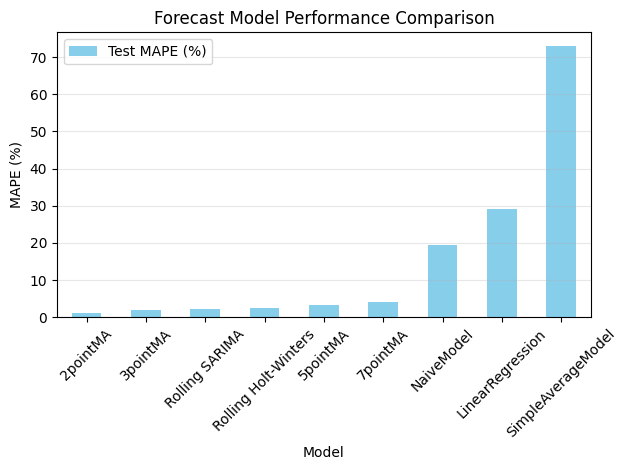

In [ ]:
# --- Final Model Comparison (MAPE) ---

# Drop duplicate models if any (keeping the first occurrence)
results_unique = results[~results.index.duplicated(keep='first')]

# Sort by Test MAPE
final_results = results_unique.sort_values('Test MAPE (%)')

# Print final results
print("\nFinal Model Comparison (unique models only):")
print(final_results)

# Plotting
plt.figure(figsize=(12, 8))
final_results.plot(kind='bar', color='skyblue')
plt.title('Forecast Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('MAPE (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# 10. Conclusion
This comprehensive analysis of gold prices demonstrates various forecasting techniques, from simple baselines to advanced time series models. The performance comparison helps identify which models are most suitable for predicting gold price movements.

Key findings from our analysis:

- Gold prices show clear long-term trends and potential structural breaks

- The data exhibits volatility clustering, captured by our GARCH model

- Comparing MAPE values across models reveals the relative forecasting power of each approach

- Rolling SARIMAX and Holt_Winters performed better than normal SARIMAX and Holt-Winters

These insights can help investors, economists, and policymakers better understand gold price dynamics and make more informed decisions.
<a class="anchor" id="section10"></a>

#           **END OF NOTEBOOK**